1. What is Supervised Learning?

 Answer:Supervised Learning is a machine learning technique in which a model learns from labeled data (input and corresponding output). The algorithm identifies patterns in the training data and uses them to predict outputs for new, unseen data. It is mainly used for regression and classification problems.

2. Difference Between Regression and Classification
Regression	Classification
Predicts continuous numerical values.	Predicts discrete categories or classes.
Output is a number.	Output is a label or class.
Example: Predicting house prices.	Example: Predicting whether an email is spam or not.
Algorithms: Linear Regression, Polynomial Regression.	Algorithms: Logistic Regression, Decision Tree, SVM.

3. What is Simple Linear Regression?

Answer:

Simple Linear Regression is a supervised learning algorithm that predicts a continuous target variable using one independent variable. It fits the best straight line between the input and output using the equation:

y = mx + c

where:

y = Predicted value
m = Slope
x = Independent variable
c = Intercept

4. Assumptions of Linear Regression

Answer:

Linear Regression assumes that:

There is a linear relationship between independent and dependent variables.
Observations are independent of each other.
The variance of errors is constant (Homoscedasticity).
Residuals are normally distributed.
Independent variables are not highly correlated (No Multicollinearity).

5. What is the Bias–Variance Trade-off?

Answer:

The Bias–Variance Trade-off describes the balance between a model that is too simple and one that is too complex. High bias can cause underfitting, while high variance can cause overfitting. The goal is to find a model that achieves the best balance for accurate predictions on new data.

6. Explain Overfitting and Underfitting with Examples

Overfitting:

Overfitting occurs when a model learns the training data too closely, including noise, resulting in poor performance on new data.

Example: A polynomial regression model of degree 10 that perfectly fits the training data but predicts new house prices poorly.

Underfitting:

Underfitting occurs when a model is too simple to capture the underlying pattern in the data, leading to poor performance on both training and testing data.

Example: Using a simple linear regression model to predict house prices when the relationship between features and price is highly non-linear.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv(1).csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4200, 12)


In [ ]:
df.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


In [ ]:
df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [ ]:
df.isnull().sum()

,0
house_id,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
age_years,0
distance_city_km,0
lot_size_sqft,0
has_garage,0
has_pool,0


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully!")

Duplicates Removed Successfully!


In [ ]:
df.shape

(4200, 12)

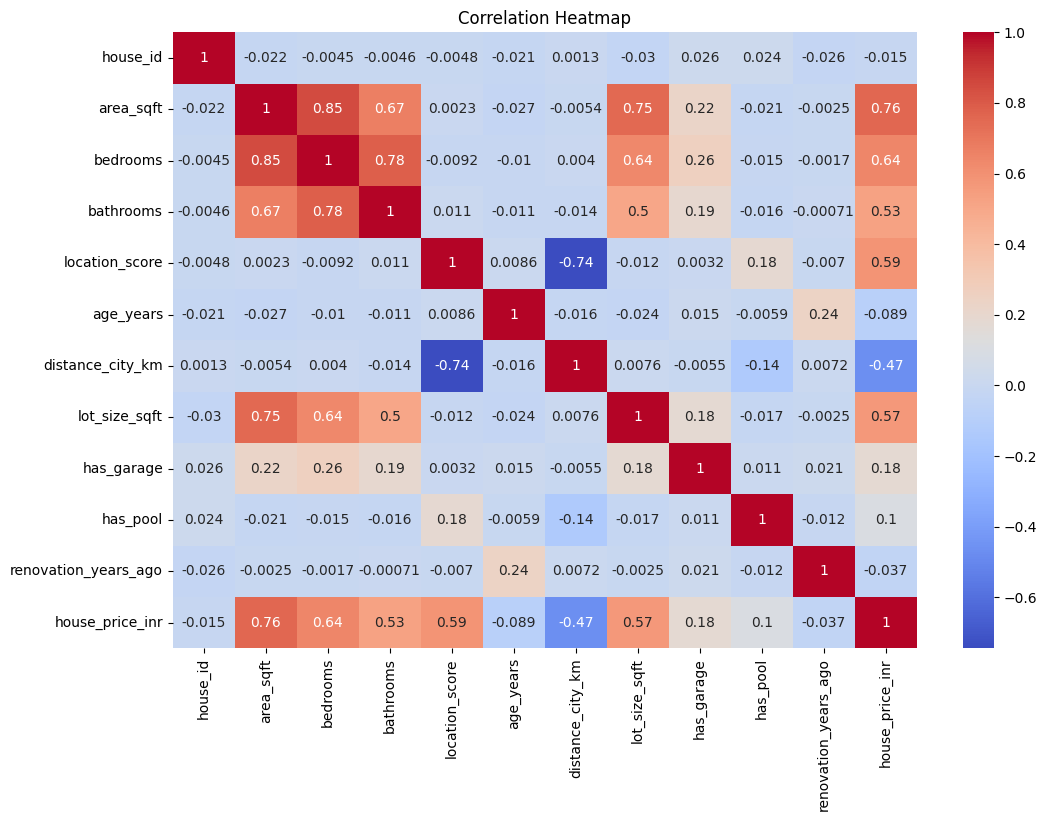

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

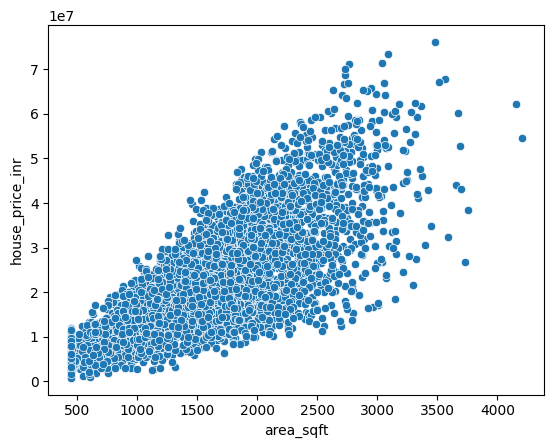

In [ ]:
sns.scatterplot(x="area_sqft",
                y="house_price_inr",
                data=df)

plt.show()

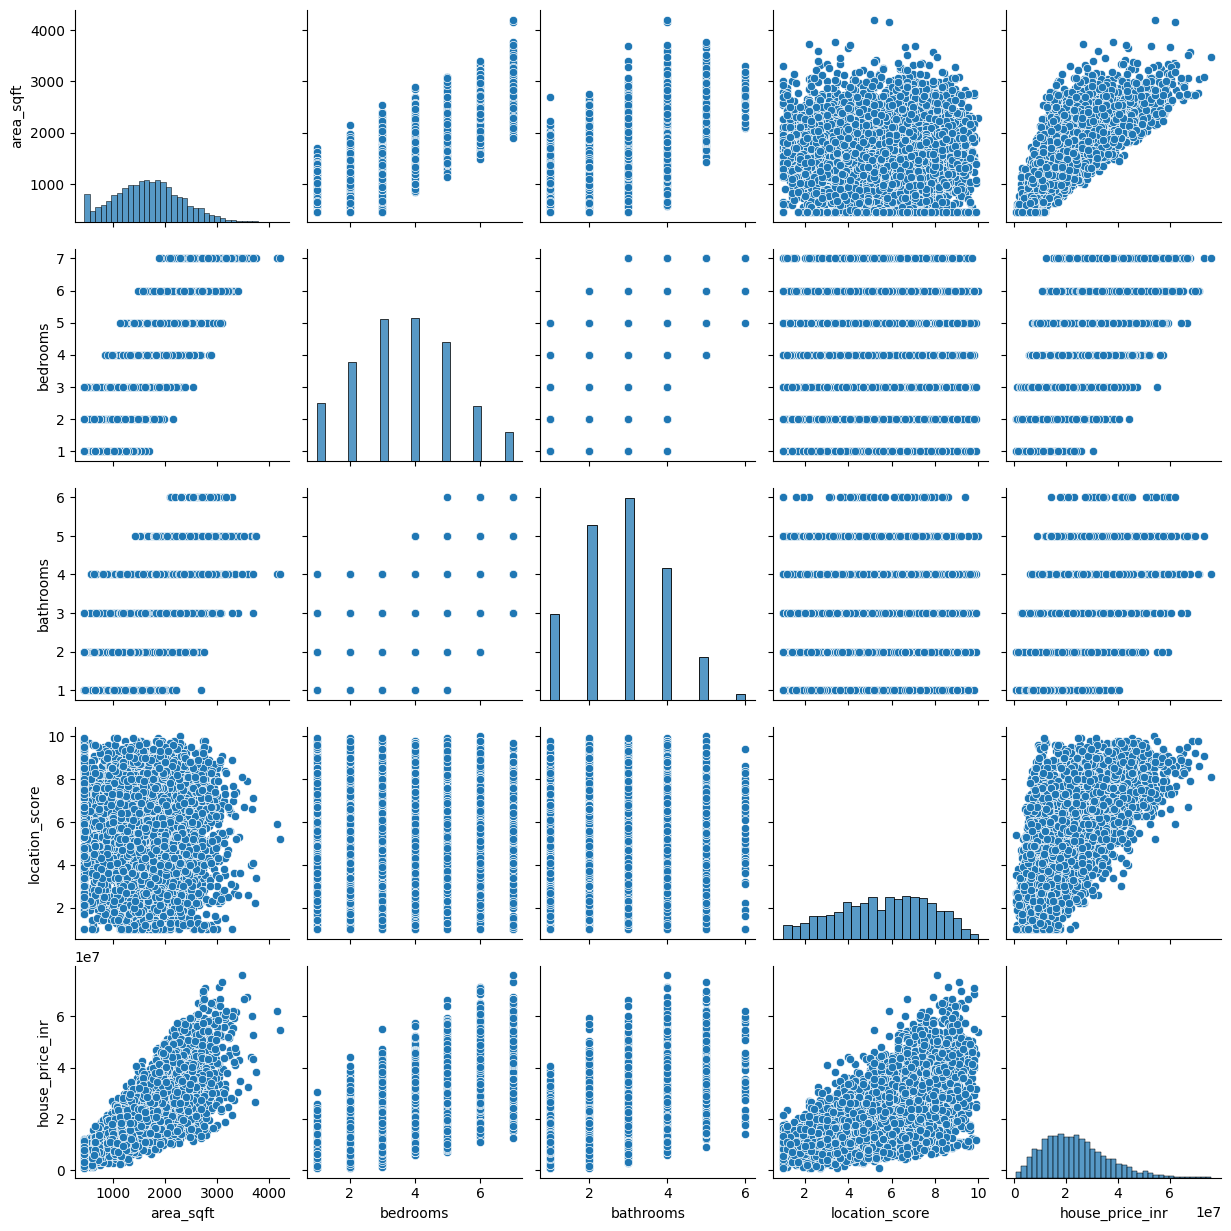

In [ ]:
sns.pairplot(df[['area_sqft',
                 'bedrooms',
                 'bathrooms',
                 'location_score',
                 'house_price_inr']])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["house_price_inr","house_id"],axis=1)
y = df["house_price_inr"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

Part C (Simple Linear Regression)

In [17]:
X=df[['area_sqft']]
y=df['house_price_inr']

In [18]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [21]:
y_pred=model.predict(X_test)

In [23]:
print(model.coef_)

[ 1.37959436e+04  1.97643105e+05  1.85944541e+05  3.07317350e+06
 -6.56092445e+04 -9.89651574e+04  1.03505816e+02  9.39243608e+04
  4.55290229e+05 -2.14359126e+04]


In [24]:
print(model.intercept_)

-14766762.745674696


Part D (Evaluation)

In [25]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MSE: 12592918884127.615
MAE: 2604991.4061556906
RMSE: 3548650.290480539
R2: 0.9177606877509898


In [26]:
n=len(y_test)
p=1

adj_r2=1-(1-r2)*(n-1)/(n-p-1)

print(adj_r2)

0.917662550146874


Part E (Multiple Linear Regression

In [27]:
X=df.drop(["house_price_inr","house_id"],axis=1)
y=df["house_price_inr"]

In [28]:
model=LinearRegression()

model.fit(X_train,y_train)

prediction=model.predict(X_test)

Part F (Polynomial Regression)

In [29]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)

X_poly=poly.fit_transform(X[['area_sqft']])

In [30]:
model=LinearRegression()

model.fit(X_poly,y)

LinearRegression()

In [31]:
poly=PolynomialFeatures(degree=3)

X_poly=poly.fit_transform(X[['area_sqft']])

Part G (Gradient Descent)

Implement

Batch Gradient Descent
Stochastic Gradient Descent
Mini Batch Gradient Descent

Compare

Convergence
Training Time
Loss

Part H

Explain

Bias
Variance

Analyze

Simple Regression
Multiple Regression
Polynomial Regression

Identify

Overfitting
Underfitting

Part I

Final Report

Include

Best Model
Why it performed best
Business Interpretation
Conclusion